# solar-radiation: efektywność przetwarzania w Spark (wsadowy vs strumieniowy)

Cel: zbadać efektywność Sparka i dobrać tryb przetwarzania danych solarnych.

1. przygotowanie danych (`bronze -> silver`),
2. szybkie sprawdzenie efektów czyszczenia,
3. uruchomienie testów,
4. eksperyment porównujący tryb wsadowy i strumieniowy oraz prezentacja wyników (`gold/report`).


In [17]:
from __future__ import annotations

import os
import subprocess
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from spark_radiation_analysis.config import load_paths

PROJECT_ROOT = Path.cwd().resolve()
paths = load_paths()
python_bin = Path(".venv/bin/python") if Path(".venv/bin/python").exists() else Path(sys.executable)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"Python: {python_bin}")
print(f"Bronze CSV: {paths.solar_csv}")
print(f"Silver dir: {paths.solar_silver_dir}")
print(f"Gold dir: {paths.solar_gold_dir}")


PROJECT_ROOT: /home/u20901042/PycharmProjects/spark-meteo-analysis
Python: .venv/bin/python
Bronze CSV: /home/u20901042/PycharmProjects/spark-meteo-analysis/data/bronze/solar-radiation/2017_2019.csv
Silver dir: /home/u20901042/PycharmProjects/spark-meteo-analysis/data/silver/solar-radiation/prepared
Gold dir: /home/u20901042/PycharmProjects/spark-meteo-analysis/data/gold/solar-radiation


## Krok 0 — Kontrola wejścia (`bronze`)
Sprawdzamy, czy plik źródłowy istnieje i podglądamy próbkę danych wejściowych.


In [18]:
assert paths.solar_csv.exists(), f"Brak pliku wejściowego: {paths.solar_csv}"

sample_bronze = pd.read_csv(paths.solar_csv, nrows=5)
display(sample_bronze)


,Year,Month,Day,Hour,Minute,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Dew Point,DHI,DNI,GHI,Relative Humidity,Solar Zenith Angle,Surface Albedo,Pressure,Wind Speed,Unnamed: 18
0,2017,1,1,0,0,-0.6,0,0,0,-2.6,0,0,0,86.29,152.92,0.12,1003,1.7,NaN
1,2017,1,1,0,15,-0.6,0,0,0,-2.6,0,0,0,86.29,150.22,0.12,1003,1.7,NaN
2,2017,1,1,0,30,-0.6,0,0,0,-2.6,0,0,0,86.29,147.43,0.12,1003,1.7,NaN
3,2017,1,1,0,45,-0.6,0,0,0,-2.7,0,0,0,85.54,144.60,0.12,1003,1.6,NaN
4,2017,1,1,1,0,-0.7,0,0,0,-2.7,0,0,0,86.17,141.71,0.12,1003,1.6,NaN


## Krok 1 — Ingestion + cleaning (`bronze -> silver`)
Uruchamiamy job `prepare_solar_radiation`, który czyści i typuje dane oraz zapisuje wynik do warstwy `silver`.


In [19]:
env = os.environ.copy()
env["PYTHONPATH"] = str(PROJECT_ROOT)

cmd = [str(python_bin), "-m", "spark_radiation_analysis.jobs.prepare_solar_radiation"]
res = subprocess.run(cmd, cwd=PROJECT_ROOT, env=env, capture_output=True, text=True)

print(res.stdout)
if res.stderr.strip():
    print("--- stderr (skrót) ---")
    print("\n".join(res.stderr.splitlines()[-40:]))

assert res.returncode == 0, f"Job zakończony błędem: {res.returncode}"


Prepared rows: 105120
Time range: 2017-01-01 01:00:00 -> 2020-01-01 00:45:00
Prepared dataset saved to: /home/u20901042/PycharmProjects/spark-meteo-analysis/data/silver/solar-radiation/prepared

--- stderr (skrót) ---
26/06/12 18:29:25 WARN Utils: Your hostname, 20901042-NTT-W-900G resolves to a loopback address: 127.0.1.1; using 192.168.0.154 instead (on interface enp69s0)
26/06/12 18:29:25 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/12 18:29:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable

[Stage 0:>                                                          (0 + 2) / 2]

                                                                                

[Stage 7:>                                                          (0 + 2) / 2]

               

## Krok 2 — Kontrola jakości po czyszczeniu (`silver`)
Weryfikujemy liczbę rekordów, zakres czasu i podstawowe warunki jakości po transformacjach.


In [20]:
from spark_radiation_analysis.analytics.solar import read_silver
from spark_radiation_analysis.spark import create_spark

spark = create_spark("notebook-solar-quality-check")
try:
    df = read_silver(spark, paths.solar_silver_dir).cache()

    summary = df.selectExpr(
        "count(*) as rows_all",
        "min(event_timestamp) as min_ts",
        "max(event_timestamp) as max_ts",
        "sum(case when event_timestamp is null then 1 else 0 end) as null_ts",
        "sum(case when GHI < 0 or DNI < 0 or DHI < 0 then 1 else 0 end) as neg_radiation_rows",
    )
    display(summary.toPandas())

    sample = df.select("event_timestamp", "GHI", "Temperature", "Relative Humidity", "Wind Speed").limit(10)
    display(sample.toPandas())
finally:
    spark.stop()


,rows_all,min_ts,max_ts,null_ts,neg_radiation_rows
0,105120,2017-01-01,2019-12-31 23:45:00,0,0


,event_timestamp,GHI,Temperature,Relative Humidity,Wind Speed
0,2017-01-01 00:00:00,0.0,-0.6,86.29,1.7
1,2017-01-01 00:15:00,0.0,-0.6,86.29,1.7
2,2017-01-01 00:30:00,0.0,-0.6,86.29,1.7
3,2017-01-01 00:45:00,0.0,-0.6,85.54,1.6
4,2017-01-01 01:00:00,0.0,-0.7,86.17,1.6
5,2017-01-01 01:15:00,0.0,-0.7,86.08,1.7
6,2017-01-01 01:30:00,0.0,-0.7,86.08,1.7
7,2017-01-01 01:45:00,0.0,-0.7,85.63,1.7
8,2017-01-01 02:00:00,0.0,-0.8,86.25,1.7
9,2017-01-01 02:15:00,0.0,-0.8,86.25,1.7


## Krok 3 — Uruchomienie testów
Uruchamiamy zestaw testów sprawdzających ingestion, analitykę i artefakty eksperymentów.


In [21]:
test_cmd = [
    str(python_bin),
    "-m",
    "unittest",
    "tests.test_ingestion",
    "tests.test_analytics",
    "tests.test_experiments",
    "tests.test_processing_compare",
    "-v",
]

test_res = subprocess.run(test_cmd, cwd=PROJECT_ROOT, env=env, capture_output=True, text=True)
print(test_res.stdout)
if test_res.stderr.strip():
    print("--- stderr (skrót) ---")
    print("\n".join(test_res.stderr.splitlines()[-60:]))

assert test_res.returncode == 0, f"Testy zakończone błędem: {test_res.returncode}"


Rows: 105120
Saved tables to: /tmp/tmp3_at18e2/gold/solar-radiation/tables
Saved report to: /tmp/tmp3_at18e2/gold/solar-radiation/report/report.md

--- stderr (skrót) ---
  return pser.astype(pandas_type, copy=False)
/home/u20901042/PycharmProjects/spark-meteo-analysis/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/types.py:570: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if necessary.
  return pser.astype(pandas_type, copy=False)
/home/u20901042/PycharmProjects/spark-meteo-analysis/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/types.py:570: Pandas4Warning: The copy keyword is deprecated and will be removed in a future version. Copy-on-Write is active in pandas since 3.0 which utilizes a lazy copy mechanism that defers copies until necessary. Use .copy() to make an eager copy if 

## Krok 4 — Eksperyment i generowanie artefaktów (`gold`)
Uruchamiamy job `solar_experiments`, który liczy wyniki analityczne aplikacji oraz przeprowadza eksperyment porównujący tryb wsadowy i strumieniowy, a następnie zapisuje tabele, wykresy i raport.


In [22]:
exp_cmd = [str(python_bin), "-m", "spark_radiation_analysis.jobs.solar_experiments"]
exp_res = subprocess.run(exp_cmd, cwd=PROJECT_ROOT, env=env, capture_output=True, text=True)

print(exp_res.stdout)
if exp_res.stderr.strip():
    print("--- stderr (skrót) ---")
    print("\n".join(exp_res.stderr.splitlines()[-40:]))

assert exp_res.returncode == 0, f"Job eksperymentów zakończony błędem: {exp_res.returncode}"


Rows: 105120
Saved tables to: /home/u20901042/PycharmProjects/spark-meteo-analysis/data/gold/solar-radiation/tables
Saved report to: /home/u20901042/PycharmProjects/spark-meteo-analysis/data/gold/solar-radiation/report/report.md

--- stderr (skrót) ---
26/06/12 18:30:00 WARN Utils: Your hostname, 20901042-NTT-W-900G resolves to a loopback address: 127.0.1.1; using 192.168.0.154 instead (on interface enp69s0)
26/06/12 18:30:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/12 18:30:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/12 18:30:07 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supported in streaming DataFrames/Datasets and will be disabled.
26/06/12 18:30:08 WARN ResolveWriteToStream: spark.sql.adaptive.enabled is not supp

## Krok 5 — Prezentacja wyników: tabele
Podgląd tabel raportowych wygenerowanych dla scenariuszy i miar jakości.


In [23]:
report_tables = paths.solar_gold_dir / "report" / "tables"

t1 = pd.read_csv(report_tables / "tabela1_profil_statystyczny.csv")
t2 = pd.read_csv(report_tables / "tabela2_korelacje.csv")
t3 = pd.read_csv(report_tables / "tabela3_profil_godzinowy.csv")
t4 = pd.read_csv(report_tables / "tabela4_jakosc_danych.csv")
t5 = pd.read_csv(report_tables / "tabela5_jakosc_analizy.csv")
t6 = pd.read_csv(report_tables / "tabela6_porownanie_trybow.csv")

display(Markdown("**Tabela 1 — Profil statystyczny zmiennych (wynik aplikacji)**"))
display(t1)

display(Markdown("**Tabela 2 — Korelacje GHI z cechami pogodowymi (wynik aplikacji)**"))
display(t2)

display(Markdown("**Tabela 3 — Profil godzinowy GHI (wynik aplikacji)**"))
display(t3.head(24))

display(Markdown("**Tabela 4 i 5 — Miary jakości danych i analizy**"))
display(t4)
display(t5)

display(Markdown("**Tabela 6 — Eksperyment: porównanie trybów przetwarzania (wsadowy vs strumieniowy)**"))
display(t6)


**Tabela 1 — Profil statystyczny zmiennych (wynik aplikacji)**

,var,n,avg,std,min,max
0,DHI,105120,60.426265,87.766074,0.00,529.0
1,DNI,105120,226.459218,330.200514,0.00,1005.0
2,GHI,105120,197.957953,291.881178,0.00,1030.0
3,Pressure,105120,992.998564,5.357458,971.00,1012.0
4,Relative Humidity,105120,67.121768,20.904710,9.53,100.0
5,Temperature,105120,18.089326,8.414004,-4.00,41.4
6,Wind Speed,105120,2.807034,1.499126,0.10,11.3


**Tabela 2 — Korelacje GHI z cechami pogodowymi (wynik aplikacji)**

,corr_ghi_temp,corr_ghi_rh,corr_ghi_wind
0,0.576992,-0.725484,0.208753


**Tabela 3 — Profil godzinowy GHI (wynik aplikacji)**

...

**Tabela 4 i 5 — Miary jakości danych i analizy**

,metric,value
0,completeness_ratio,1.0
1,non_negative_radiation_ratio,1.0


,metric,value
0,mean_abs_corr_ghi_weather,0.503743
1,hourly_peak_to_mean_ghi,3.231525


**Tabela 6 — Eksperyment: porównanie trybów przetwarzania (wsadowy vs strumieniowy)**

,agg_rows,input_rows,median_seconds,min_seconds,mode,rows_per_sec,runs
0,24,105120,0.157975,0.148917,wsadowy,665420.918366,3
1,24,105120,0.396352,0.374750,strumieniowy,265218.739205,3


## Krok 6 — Prezentacja wyników: wykresy i raport
Wyświetlamy wykresy oraz treść raportu końcowego.


**Wykres 1 — Średnie GHI w godzinach doby (wynik aplikacji)**

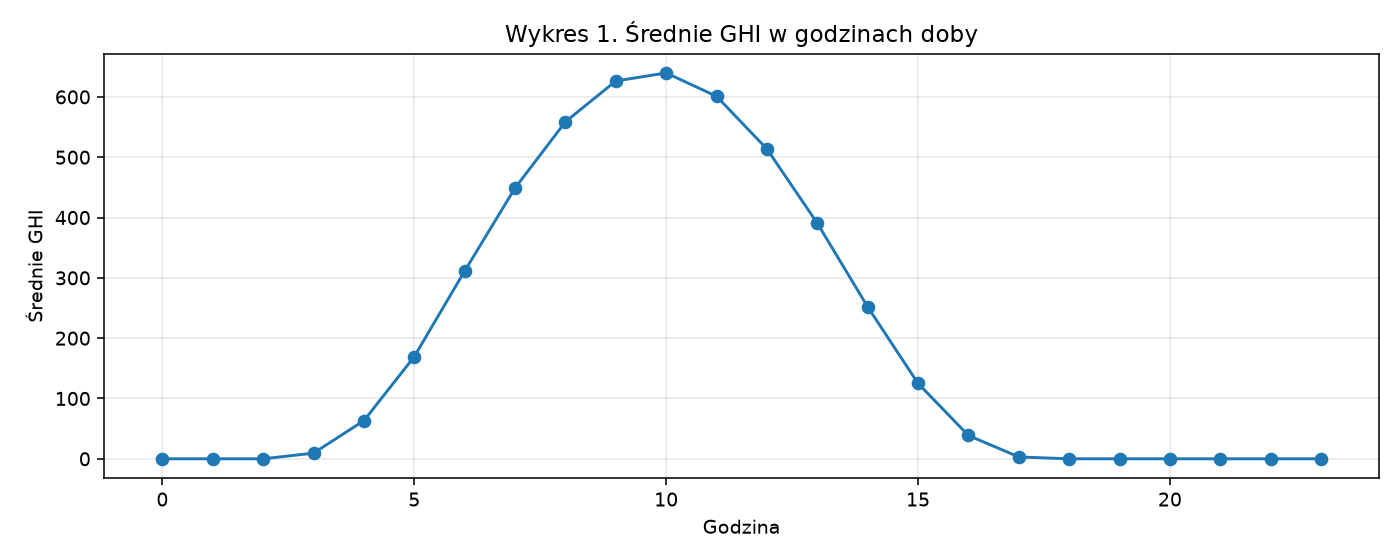

**Wykres 2 — Korelacje GHI z cechami pogodowymi (wynik aplikacji)**

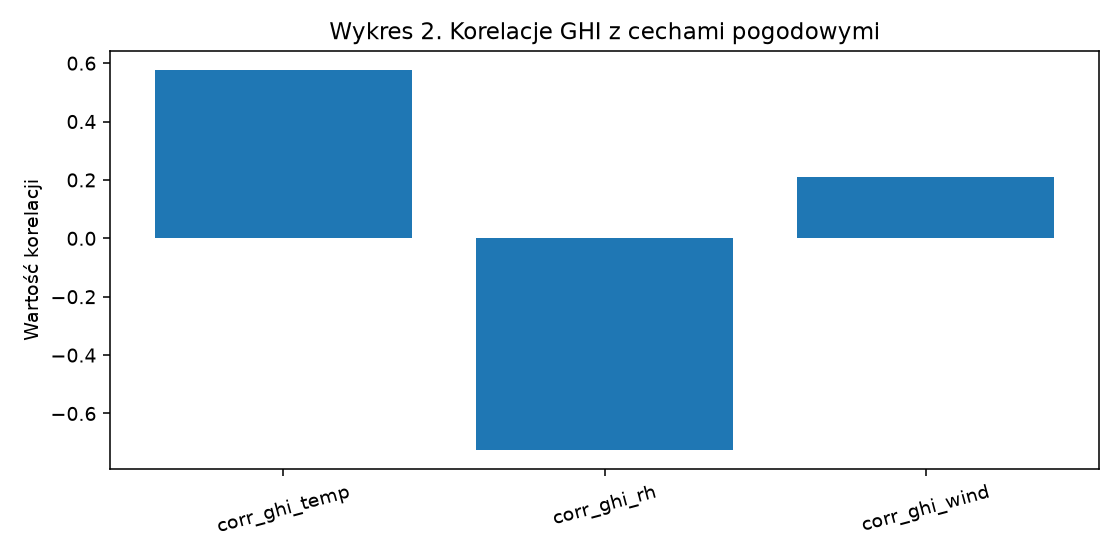

**Wykres 3 — Eksperyment: mediana czasu przetwarzania (wsadowy vs strumieniowy)**

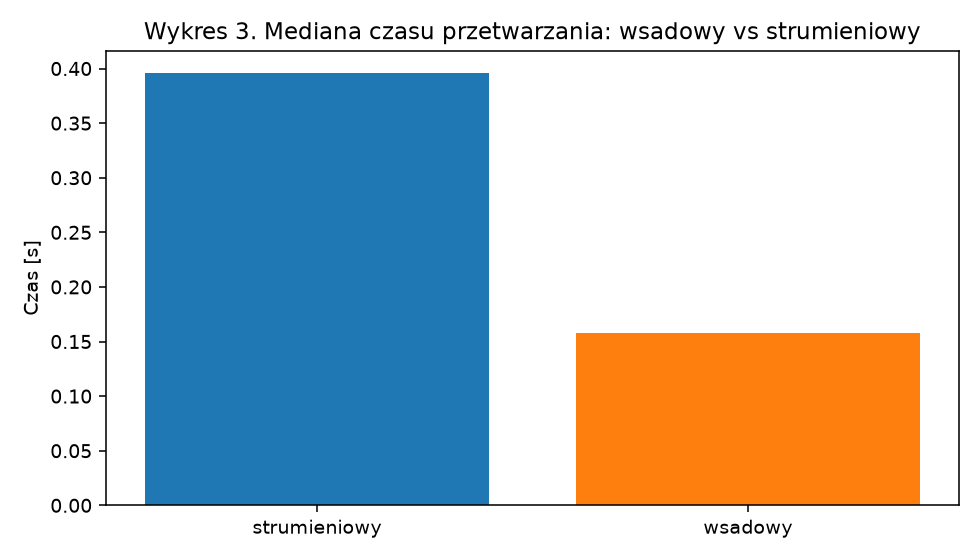

**Wykres 4 — Eksperyment: przepustowość przetwarzania (wsadowy vs strumieniowy)**

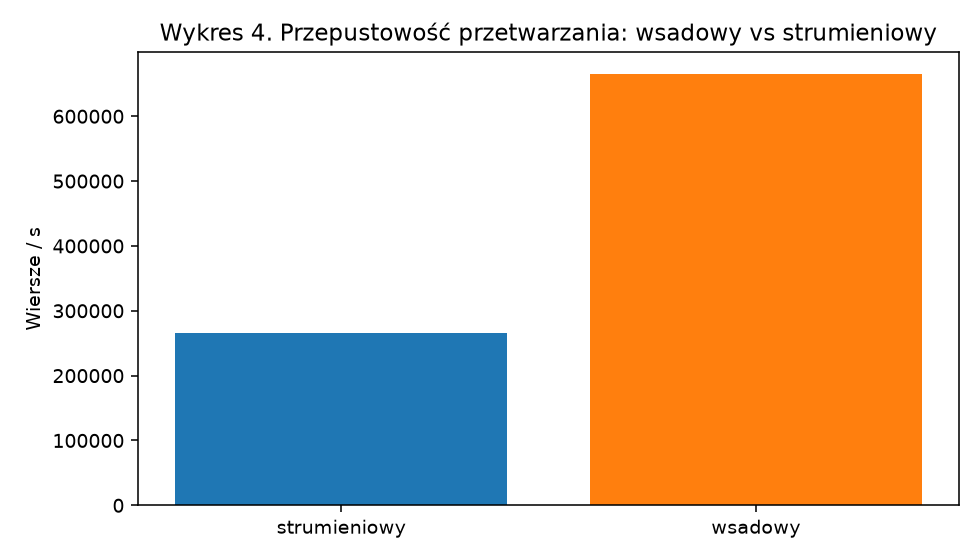

**Raport tekstowy**

## Raport: efektywność przetwarzania danych solar-radiation w Spark

Celem projektu jest zbadanie efektywności narzędzia Spark oraz dobór trybu
przetwarzania (wsadowy vs strumieniowy) dla danych meteorologicznych/solarnych.
Aplikacja przykładowa realizuje czyszczenie danych i analizę promieniowania,
a eksperyment porównuje oba tryby na tym samym potoku obliczeniowym.

### Aplikacja i jej wyniki analityczne
Aplikacja wczytuje surowe dane CSV (`bronze`), czyści i typuje je (`silver`)
oraz liczy statystyki i zależności promieniowania:
- **Tabela 1** (`tabela1_profil_statystyczny.csv`) — profil statystyczny zmiennych.
- **Tabela 2** (`tabela2_korelacje.csv`) — korelacje `GHI` z temperaturą/wilgotnością/wiatrem.
- **Tabela 3** (`tabela3_profil_godzinowy.csv`) — średnie godzinowe.
- **Wykres 1** (`charts/wykres1_ghi_godziny.png`) — dzienny profil `GHI`.
- **Wykres 2** (`charts/wykres2_korelacje.png`) — siła i znak korelacji.

Jakość danych wejściowych (Tabela 4 i 5) potwierdza wiarygodność tych wyników:
kompletność = `1.0000`, udział nieujemnego promieniowania = `1.0000`.

Krótka interpretacja: Wykres 1 i Tabela 3 pokazują dzienny profil promieniowania
z maksimum w środku dnia, a Wykres 2/Tabela 2 potwierdzają zależności `GHI`
z cechami pogodowymi (średnia |korelacja| = `0.5037`, stosunek szczyt/średnia
profilu godzinowego = `3.2315`).

### Eksperyment: porównanie trybów przetwarzania (rdzeń projektu)
Definiujemy dwa scenariusze przetwarzania tego samego workloadu
(czyszczenie + agregacja godzinowa `GHI`):
1. **Scenariusz wsadowy** — przetwarzanie wsadowe pełnego pliku.
2. **Scenariusz strumieniowy** — Structured Streaming z wyzwalaczem jednorazowym.

Miary jakości/wydajności (min. 2):
- **M1: mediana czasu przetwarzania** (z 3 powtórzeń po rozgrzewce).
- **M2: przepustowość** (`rows_per_sec`).
- Kontrola spójności wyniku: liczba wierszy agregacji w obu trybach.

- **Wsadowy**: mediana = `0.1580` s, przepustowość = `665420.92` wierszy/s, wierszy wyniku = `24`.
- **Strumieniowy**: mediana = `0.3964` s, przepustowość = `265218.74` wierszy/s, wierszy wyniku = `24`.
- Spójność wyników między trybami: **tak**.
- Szybszy tryb w tym przebiegu: **wsadowy** (ok. 2.51x; patrz Tabela 6, Wykres 3 i 4).

### Wnioski i dalsze kierunki
- Oba tryby dają identyczny wynik analityczny, więc wybór trybu jest decyzją wydajnościowo-operacyjną.
- Dla tego pilotażowego zbioru (dane statyczne, ~10 MB) szybszy jest tryb **wsadowy**: przetwarzanie wsadowe nie ponosi narzutu mikro-batchy i checkpointów typowego dla strumienia.
- Tryb strumieniowy ma sens, gdy dane napływają w sposób ciągły (np. odczyty stacji w czasie rzeczywistym), kosztem stałego narzutu — co potwierdza wyższy czas przy jednorazowym przetworzeniu pliku.
- Dalsze kroki: pomiar przy rosnącym wolumenie danych, wpływ liczby partycji `spark.sql.shuffle.partitions` oraz triggera (`once` vs `processingTime`) na czas i przepustowość.

In [24]:
report_dir = paths.solar_gold_dir / "report"
charts_dir = report_dir / "charts"

display(Markdown("**Wykres 1 — Średnie GHI w godzinach doby (wynik aplikacji)**"))
display(Image(filename=str(charts_dir / "wykres1_ghi_godziny.png")))

display(Markdown("**Wykres 2 — Korelacje GHI z cechami pogodowymi (wynik aplikacji)**"))
display(Image(filename=str(charts_dir / "wykres2_korelacje.png")))

display(Markdown("**Wykres 3 — Eksperyment: mediana czasu przetwarzania (wsadowy vs strumieniowy)**"))
display(Image(filename=str(charts_dir / "wykres3_czas_przetwarzania.png")))

display(Markdown("**Wykres 4 — Eksperyment: przepustowość przetwarzania (wsadowy vs strumieniowy)**"))
display(Image(filename=str(charts_dir / "wykres4_przepustowosc.png")))

report_text = (report_dir / "report.md").read_text(encoding="utf-8")
display(Markdown("**Raport tekstowy**"))
display(Markdown(report_text))
